In [11]:
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sys.path.insert(0, str(Path.cwd().parent))

### Quality Control
You walk onto the factory floor and pull 5 bottles off the line. You measure them:
- Measurements (ml): 498, 497, 499, 496, 495
- Average: 497ml

The "Null Hypothesis" ($H_0$) is that the machine is calibrated to 500ml. Even though your average is 497ml, is that "close enough" to be luck? Or is the machine actually drifting? With only 5 bottles, the "noise" is high. If the standard deviation is 2ml, a 497ml average might actually be quite rare—triggering you to hit the "Stop" button.

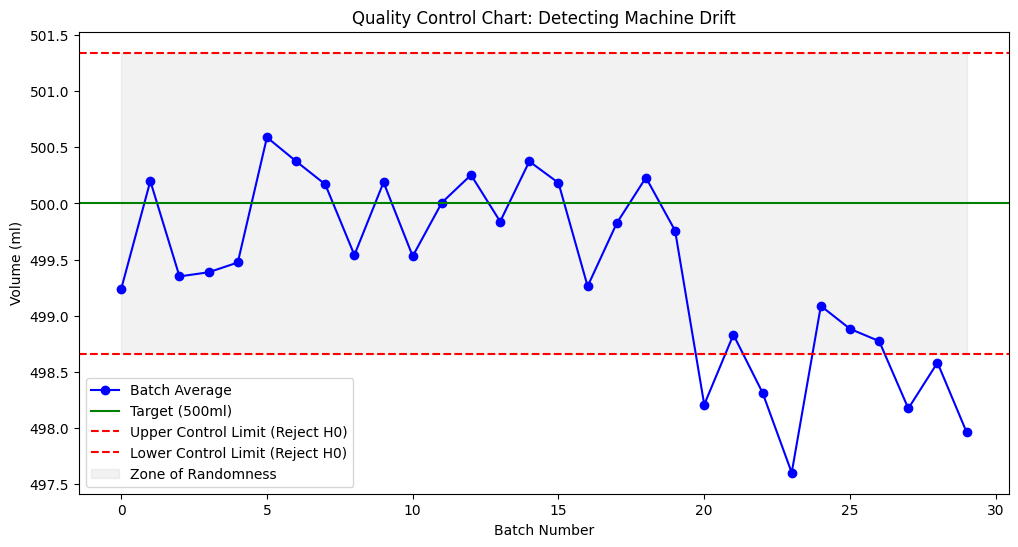

In [16]:
# 1. Setup: Machine is set to 500ml with a standard deviation of 1ml
target = 500
sigma = 1.0
n_samples = 30  # 30 batches of 5 bottles each

# Generate "Normal" data
# Two-thirds of the data is from a stable process, and one-third is from a drifting process
stable_process = np.random.normal(
    target, sigma, (int(n_samples * 2 / 3), 5)
)  # rows are batches, columns are individual bottle measurements

# Generate "Drifting" data (the machine starts failing)
drifting_process = np.random.normal(target - 1.5, sigma, (int(n_samples * 1 / 3), 5))

# Combine and calculate means for each batch
all_batches = np.vstack([stable_process, drifting_process])
batch_means = all_batches.mean(axis=1)

# 2. Calculate Control Limits (Hypothesis Test Thresholds)
# Typically, we use 3 standard errors from the mean (99.7% confidence)
standard_error = sigma / np.sqrt(5)
ucl = target + (3 * standard_error)  # Upper Control Limit
lcl = target - (3 * standard_error)  # Lower Control Limit

# 3. Visualization
plt.figure(figsize=(12, 6))
plt.plot(batch_means, marker="o", linestyle="-", color="b", label="Batch Average")
plt.axhline(target, color="green", label="Target (500ml)")
plt.axhline(ucl, color="red", linestyle="--", label="Upper Control Limit (Reject H0)")
plt.axhline(lcl, color="red", linestyle="--", label="Lower Control Limit (Reject H0)")

plt.fill_between(
    range(len(batch_means)),
    lcl,
    ucl,
    color="gray",
    alpha=0.1,
    label="Zone of Randomness",
)
plt.title("Quality Control Chart: Detecting Machine Drift")
plt.xlabel("Batch Number")
plt.ylabel("Volume (ml)")
plt.legend()
plt.show()

### The "Loud Minority" vs. The Market
Imagine you survey 100 people at a local mall. 55 say they prefer Toyota and 45 say Honda.
- **The Marketer**: "Toyota is 10 points ahead! Let's feature this in our next Super Bowl ad."
- **The Statistician**: "Wait. If the whole city actually likes them exactly 50/50, how likely is it that I'd just happen to pick 55 Toyota fans by pure chance?"
Hypothesis testing is the tool that tells the marketer, "Don't spend that $7 million on the ad yet; that 10-point lead might just be a fluke of who was at the mall that day."

To be sure, we'd use a Chi-Squared Test or a Z-test for two proportions. If the "p-value" comes back at 0.15, it means there's a 15% chance this shift happened randomly. Most businesses want that risk to be under 5% ($\alpha = 0.05$) before changing strategy.

**Real-World "Auto" Pitfall: The Regional Bias**
In the auto industry, a common mistake is ignoring geographic clusters. If you survey 1,000 people but they are all from Southern California, your "Toyota vs. Honda" results are valid only for that region. Statisticians use hypothesis testing combined with Stratified Sampling to ensure that if they say "Americans prefer Toyota," they aren't accidentally just reporting that "People in snowy climates prefer Subaru."

Result: Not Significant (p=0.0643). The brands are perceived equally.


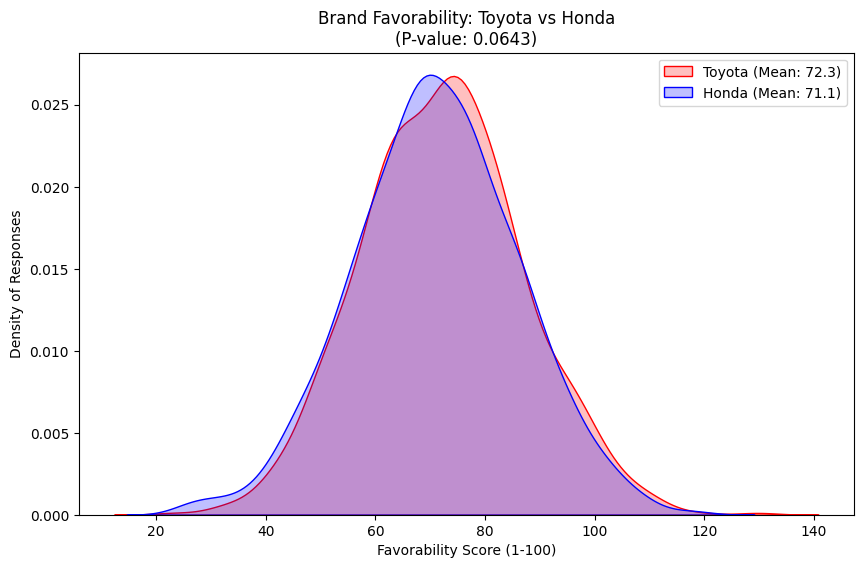

In [17]:
# 1. Simulate Survey Data (1000 respondents for each)
np.random.seed(42)
# Toyota: Mean score 72, SD 15
toyota_scores = np.random.normal(72, 15, 1000)
# Honda: Mean score 70, SD 15 (A very small difference!)
honda_scores = np.random.normal(70, 15, 1000)

# 2. Perform the T-test
# Null Hypothesis (H0): There is NO difference in average favorability.
t_stat, p_val = stats.ttest_ind(toyota_scores, honda_scores)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.kdeplot(
    toyota_scores,
    label=f"Toyota (Mean: {toyota_scores.mean():.1f})",
    fill=True,
    color="red",
)
sns.kdeplot(
    honda_scores,
    label=f"Honda (Mean: {honda_scores.mean():.1f})",
    fill=True,
    color="blue",
)

plt.title(f"Brand Favorability: Toyota vs Honda\n(P-value: {p_val:.4f})")
plt.xlabel("Favorability Score (1-100)")
plt.ylabel("Density of Responses")
plt.legend()

# Decision Logic
alpha = 0.05
if p_val < alpha:
    print(f"Result: Significant! (p={p_val:.4f}). We can claim a preference.")
else:
    print(f"Result: Not Significant (p={p_val:.4f}). The brands are perceived equally.")

plt.show()

Suppose you have two versions of a digital ad. You show them to a small pilot group:
- **Ad A (Control)**: 100 clicks out of 1000 views (10% rate)
- **Ad B (Treatment)**: 120 clicks out of 1000 views (12% rate)
At first glance, Ad B is 20% better. But is it? If we assume the "Null Hypothesis" (that the ads are actually identical), we use a standard error calculation to see if a 2% difference is common. For this sample size, a 2% gap often happens just by chance. A hypothesis test prevents you from declaring a "winner" prematurely and swapping your entire ad budget to a version that isn't actually better.

Group A observed rate: 0.1000
Group B observed rate: 0.0970


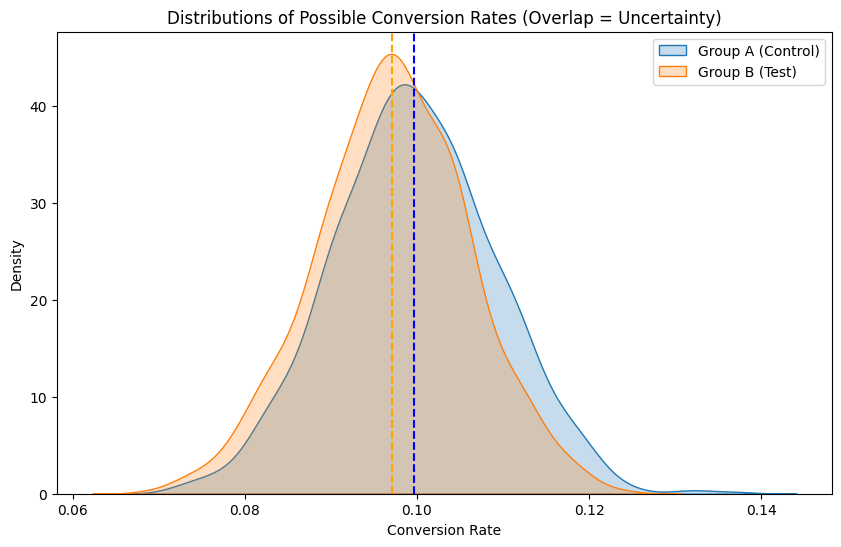

No significant difference. (p=0.8220)


In [22]:
# Settings: Two groups with the EXACT same true conversion rate (0.10)
# This represents the "Null Hypothesis" being true.
np.random.seed(42)
n_users = 1000
true_rate = 0.10

group_a = np.random.binomial(1, true_rate, n_users)
group_b = np.random.binomial(1, true_rate, n_users)

# Even though they are the same, let's see the observed means
print(f"Group A observed rate: {group_a.mean():.4f}")
print(f"Group B observed rate: {group_b.mean():.4f}")


# Visualizing the uncertainty
# We'll use a Bootstrap to show how much the means could fluctuate
def bootstrap_means(data, iterations=1000):
    return [
        np.random.choice(data, len(data), replace=True).mean()
        for _ in range(iterations)
    ]


a_means = bootstrap_means(group_a)
b_means = bootstrap_means(group_b)

plt.figure(figsize=(10, 6))
sns.kdeplot(a_means, label="Group A (Control)", fill=True)
sns.kdeplot(b_means, label="Group B (Test)", fill=True)
plt.axvline(np.mean(a_means), color="blue", linestyle="--")
plt.axvline(np.mean(b_means), color="orange", linestyle="--")
plt.title("Distributions of Possible Conversion Rates (Overlap = Uncertainty)")
plt.xlabel("Conversion Rate")
plt.legend()
plt.show()

# Perform a formal T-test
t_stat, p_val = stats.ttest_ind(group_a, group_b)
if p_val < 0.05:
    print(f"Significant difference detected! (p={p_val:.4f})")
else:
    print(f"No significant difference. (p={p_val:.4f})")

### Price Elasticity and Sales Volumne
Imagine your dealership typically sells 100 SUVs a month at a $500 margin. You decide to hike the price by $5, increasing your margin to $505.

- The Goal: You want the extra $5 profit per car to outweigh any loss in customers.
- The Problem: Car sales fluctuate every week anyway because of the weather, holidays, or even a competitor's TV ad.

If you sell 98 cars this month instead of 100, is that because of your $5 price hike (Elasticity), or just a "slow month" (Variance)? Hypothesis testing allows you to set a confidence interval around your sales volume so you don't panic and drop prices back down over a random 2-unit dip.

Let's simulate 52 weeks (one year) of sales data and see if our hypothesis test can detect a genuine change in elasticity versus random weekly noise.

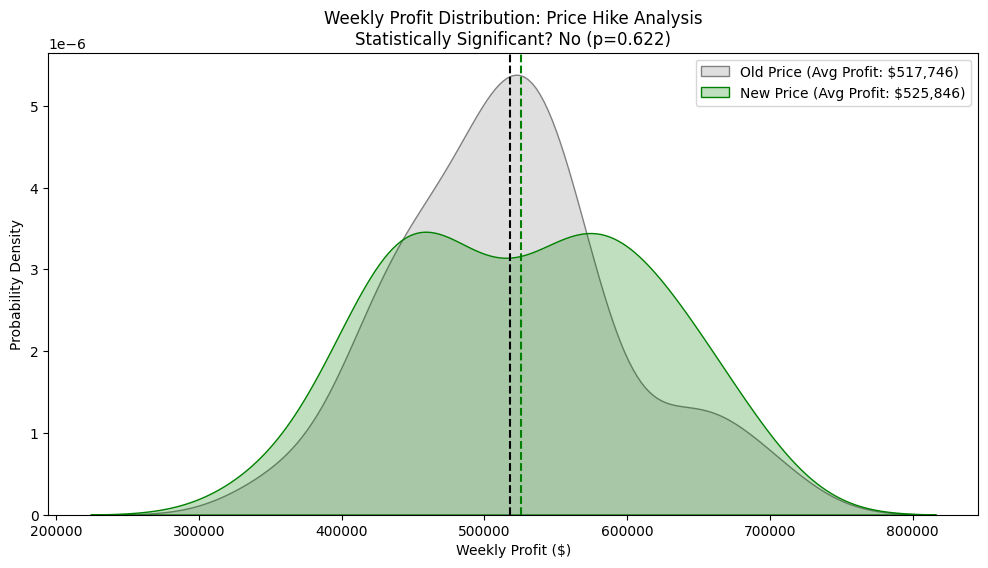

P-value: 0.6224


In [25]:
# 1. Simulate 52 weeks of sales data
np.random.seed(101)
weeks = np.arange(1, 53)

# Base scenario: Price = $30,000, Mean Sales = 100/week, SD = 15
price_old = 30000
sales_old = np.random.normal(100, 15, 52)

# New scenario: Price = $30,500, Mean Sales = 95/week (Real drop), SD = 15
price_new = 30500
sales_new = np.random.normal(95, 15, 52)  # Slightly lower volume

# 2. Calculate Profit
# Assume cost per unit is $25,000
cost_per_unit = 25000
margin_old = price_old - cost_per_unit
margin_new = price_new - cost_per_unit

profit_old = sales_old * margin_old
profit_new = sales_new * margin_new

# 3. Hypothesis Test: Is the profit actually different?
t_stat, p_val = stats.ttest_ind(profit_new, profit_old)

# 4. Visualization
plt.figure(figsize=(12, 6))

# Plotting the Profit distributions
sns.kdeplot(
    profit_old,
    label=f"Old Price (Avg Profit: ${profit_old.mean():,.0f})",
    fill=True,
    color="gray",
)
sns.kdeplot(
    profit_new,
    label=f"New Price (Avg Profit: ${profit_new.mean():,.0f})",
    fill=True,
    color="green",
)

plt.title(
    f"Weekly Profit Distribution: Price Hike Analysis\nStatistically Significant? {'Yes' if p_val < 0.05 else 'No'} (p={p_val:.3f})"
)
plt.xlabel("Weekly Profit ($)")
plt.ylabel("Probability Density")
plt.axvline(profit_old.mean(), color="black", linestyle="--")
plt.axvline(profit_new.mean(), color="green", linestyle="--")
plt.legend()
plt.show()

print(f"P-value: {p_val:.4f}")

**The Business Takeaway**
In the code output, you'll often see that even if the average profit looks higher with the new price, the p-value might be 0.20 or 0.30.

In the auto industry, this is a "Hold" signal. It tells the executive: "The math says we can't prove this price hike is actually helping us yet. The gain we see could easily be erased by a rainy weekend next month."

Required weeks per group: 883.96


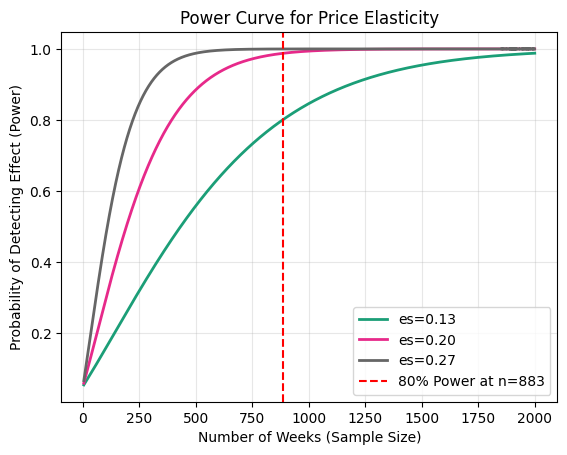

In [26]:
from statsmodels.stats.power import TTestIndPower

# 1. Define Parameters
effect_size_raw = 200  # The profit change we want to detect
std_dev = 1500  # Historical noise/variance
alpha = 0.05  # 5% False Alarm risk
power = 0.80  # 80% chance of success

# Cohen's d (Standardized Effect Size)
# This is (Mean1 - Mean2) / Pooled Standard Deviation
d = effect_size_raw / std_dev

# 2. Calculate Sample Size
analysis = TTestIndPower()
n_weeks = analysis.solve_power(effect_size=d, alpha=alpha, power=power, ratio=1.0)

print(f"Required weeks per group: {n_weeks:.2f}")

# 3. Visualization: Power Curve
# Shows how Power increases as we add more weeks/data
sample_sizes = np.array(range(5, 2000))
analysis.plot_power(dep_var="nobs", nobs=sample_sizes, effect_size=[d, d * 1.5, d * 2])
plt.title("Power Curve for Price Elasticity")
plt.axvline(
    n_weeks, color="red", linestyle="--", label=f"80% Power at n={int(n_weeks)}"
)
plt.ylabel("Probability of Detecting Effect (Power)")
plt.xlabel("Number of Weeks (Sample Size)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()